<a href="https://colab.research.google.com/github/Saransh3041/E-Commerce-Sales-EDA/blob/main/E_Commerce_sales_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Reading the sales dataset into a pandas DataFrame
# 'sales_dataset.csv' should be in the working directory

df2=pd.read_csv('/content/sales_dataset.csv')
df2.head(4)

/tmp/ipython-input-1256728417.py:4: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  df2=pd.read_csv('/content/sales_dataset.csv')


,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,405-8078784-5731545,30-04-2022,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,171-9198151-1101146,30-04-2022,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,404-0687676-7273146,30-04-2022,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,403-9615377-8133951,30-04-2022,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN


In [ ]:
# -------------------- Converting Date Column --------------------

# Converting 'Date' column to datetime format
# Format is set to 'day-month-year' (e.g., 25-08-2024)

df2['Date'] = pd.to_datetime(df2['Date'], format='%d-%m-%Y', errors='coerce')


In [ ]:
# -------------------- Extracting Month Information --------------------

# Counting how many records exist for each month

df2['Date'].dt.month.value_counts()

,count
Date,
4,49058
5,42035
6,37685
3,171


In [ ]:
# Checking general information about the dataset
# (column names, non-null counts, and data types)

df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128949 entries, 0 to 128948
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Order ID            128949 non-null  object        
 1   Date                128949 non-null  datetime64[ns]
 2   Status              128949 non-null  object        
 3   Fulfilment          128949 non-null  object        
 4   Sales Channel       128949 non-null  object        
 5   ship-service-level  128949 non-null  object        
 6   Style               128949 non-null  object        
 7   SKU                 128949 non-null  object        
 8   Category            128949 non-null  object        
 9   Size                128949 non-null  object        
 10  ASIN                128949 non-null  object        
 11  Courier Status      122078 non-null  object        
 12  Qty                 128949 non-null  int64         
 13  currency            121155 no

In [ ]:
# Set the 'Status' column as the new index for the DataFrame.

df2=df2.set_index('Status')

In [ ]:
# Then, use .fillna(0.0) to replace any missing values (NaN) in the 'Amount' column with 0.0.


df2.loc['Cancelled','Amount'] = df2.loc['Cancelled','Amount'].fillna(0.0)


In [ ]:
df2.reset_index(inplace=True)

In [ ]:
# -------------------- Handling Missing Values --------------------

# Filling missing values in 'Amount' column with median
df2.Amount.fillna(df2['Amount'].median(),inplace=True)

/tmp/ipython-input-3917085501.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2.Amount.fillna(df2['Amount'].median(),inplace=True)


In [ ]:
# Checking if any null values still exist in 'Amount'

df2.Amount.isnull()


,Amount
0,False
1,False
2,False
3,False
4,False
...,...
128944,False
128945,False
128946,False
128947,False


In [ ]:
# Filling missing values in 'currency' column with 'INR'
df2.currency.fillna('INR',inplace=True)

/tmp/ipython-input-1875287779.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2.currency.fillna('INR',inplace=True)


In [ ]:
# Checking if any null values still exist in 'currency'
df2.currency.isnull()

,currency
0,False
1,False
2,False
3,False
4,False
...,...
128944,False
128945,False
128946,False
128947,False


In [ ]:
# -------------------- Cleaning 'Status' Column --------------------

# Checking frequency of each unique value in 'Status' column
df2.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128949 entries, 0 to 128948
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Status              128949 non-null  object        
 1   Order ID            128949 non-null  object        
 2   Date                128949 non-null  datetime64[ns]
 3   Fulfilment          128949 non-null  object        
 4   Sales Channel       128949 non-null  object        
 5   ship-service-level  128949 non-null  object        
 6   Style               128949 non-null  object        
 7   SKU                 128949 non-null  object        
 8   Category            128949 non-null  object        
 9   Size                128949 non-null  object        
 10  ASIN                128949 non-null  object        
 11  Courier Status      122078 non-null  object        
 12  Qty                 128949 non-null  int64         
 13  currency            128949 no

In [ ]:
# Replacing 'Shipped' and 'Shipping' with 'Dispatched'

df2['Status'].replace({'Shipped':'Dispatched'},inplace=True)
df2['Status'].replace({'Shipping':'Dispatched'},inplace=True)
# Updating 'Pending' to make it more descriptive

df2['Status'].replace({'Pending':'Pending - Waiting for Pick Up'},inplace=True)

/tmp/ipython-input-2001395340.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2['Status'].replace({'Shipped':'Dispatched'},inplace=True)


In [ ]:



# Checking updated value counts in 'Status'


df2.Status.value_counts()

,count
Status,
Dispatched,77775
Shipped - Delivered to Buyer,28771
Cancelled,18341
Shipped - Returned to Seller,1953
Shipped - Picked Up,973
Pending - Waiting for Pick Up,939
Shipped - Returning to Seller,145
Shipped - Out for Delivery,35
Shipped - Rejected by Buyer,11


In [ ]:
# Replacing long-form status values for consistency

df2.Status.replace({'Shipped - Picked Up':'Shipped - Picked Up by Courier'},inplace=True)

In [ ]:
df2.Status.replace({'Dispatched':'Dispatched - Not Picked Up'},inplace=True)

In [ ]:
# Checking updated dataset information

df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128949 entries, 0 to 128948
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Status              128949 non-null  object        
 1   Order ID            128949 non-null  object        
 2   Date                128949 non-null  datetime64[ns]
 3   Fulfilment          128949 non-null  object        
 4   Sales Channel       128949 non-null  object        
 5   ship-service-level  128949 non-null  object        
 6   Style               128949 non-null  object        
 7   SKU                 128949 non-null  object        
 8   Category            128949 non-null  object        
 9   Size                128949 non-null  object        
 10  ASIN                128949 non-null  object        
 11  Courier Status      122078 non-null  object        
 12  Qty                 128949 non-null  int64         
 13  currency            128949 no

In [ ]:
# -------------------- Handling Courier Information --------------------
# Filling missing values in 'Courier Status' with 'Cancelled'

df2['Courier Status']=df2['Courier Status'].fillna('Cancelled')

In [ ]:
# Checking if any null values still exist in 'Courier Status'

df2['Courier Status'].isnull()

,Courier Status
0,False
1,False
2,False
3,False
4,False
...,...
128944,False
128945,False
128946,False
128947,False


In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128949 entries, 0 to 128948
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Status              128949 non-null  object        
 1   Order ID            128949 non-null  object        
 2   Date                128949 non-null  datetime64[ns]
 3   Fulfilment          128949 non-null  object        
 4   Sales Channel       128949 non-null  object        
 5   ship-service-level  128949 non-null  object        
 6   Style               128949 non-null  object        
 7   SKU                 128949 non-null  object        
 8   Category            128949 non-null  object        
 9   Size                128949 non-null  object        
 10  ASIN                128949 non-null  object        
 11  Courier Status      128949 non-null  object        
 12  Qty                 128949 non-null  int64         
 13  currency            128949 no

In [ ]:
# -------------------- Handling Country Information --------------------

# Identifying rows with missing 'ship-country'
null=df2['ship-country'].isnull()

In [ ]:
df2[null]

,Status,Order ID,Date,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
1862,Dispatched - Not Picked Up,404-0566904-4825137,2022-04-29,Amazon,Amazon.in,Expedited,J0301,J0301-TP-L,Top,L,...,INR,493.0,NaN,NaN,NaN,NaN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
1863,Dispatched - Not Picked Up,404-0566904-4825137,2022-04-29,Amazon,Amazon.in,Expedited,JNE3697,JNE3697-KR-L,kurta,L,...,INR,458.0,NaN,NaN,NaN,NaN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
8743,Dispatched - Not Picked Up,406-4003386-8768363,2022-04-25,Amazon,Amazon.in,Expedited,JNE3376,JNE3376-KR-M,kurta,M,...,INR,432.0,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN
11206,Dispatched - Not Picked Up,402-0107720-7057168,2022-04-23,Amazon,Amazon.in,Expedited,J0003,J0003-SET-S,Set,S,...,INR,654.0,NaN,NaN,NaN,NaN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
13243,Cancelled,407-4532637-8415521,2022-04-22,Merchant,Amazon.in,Standard,JNE3405,JNE3405-KR-S,kurta,S,...,INR,380.0,NaN,NaN,NaN,NaN,NaN,False,Easy Ship,NaN
15679,Dispatched - Not Picked Up,404-9229894-8608305,2022-04-21,Amazon,Amazon.in,Expedited,JNE3510,JNE3510-KR-M,kurta,M,...,INR,442.0,NaN,NaN,NaN,NaN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
16778,Shipped - Delivered to Buyer,402-4919636-4333150,2022-04-20,Merchant,Amazon.in,Standard,JNE1233,JNE1233-BLUE-KR-031-XXXL,kurta,3XL,...,INR,376.0,NaN,NaN,NaN,NaN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
18342,Dispatched - Not Picked Up,405-4927647-8064368,2022-04-19,Amazon,Amazon.in,Expedited,J0230,J0230-SKD-XS,Set,XS,...,INR,1112.0,NaN,NaN,NaN,NaN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
22921,Shipped - Returned to Seller,402-8628677-0457954,2022-04-16,Merchant,Amazon.in,Standard,J0003,J0003-SET-S,Set,S,...,INR,654.0,NaN,NaN,NaN,NaN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
24977,Cancelled,406-4079063-8291520,2022-04-15,Amazon,Amazon.in,Expedited,JNE3567,JNE3567-KR-XXL,kurta,XXL,...,INR,399.0,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN


In [ ]:
# Filling missing values in 'ship-country' with 'INR' (default country)

df2['ship-country'].fillna('INR',inplace=True)


/tmp/ipython-input-3202350945.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2['ship-country'].fillna('INR',inplace=True)


In [ ]:
# -------------------- Dropping Unnecessary Columns --------------------

# Dropping unwanted column 'Unnamed: 22' (likely extra blank column from CSV)
df2.drop(columns='Unnamed: 22',inplace=True)

In [ ]:

df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128949 entries, 0 to 128948
Data columns (total 22 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Status              128949 non-null  object        
 1   Order ID            128949 non-null  object        
 2   Date                128949 non-null  datetime64[ns]
 3   Fulfilment          128949 non-null  object        
 4   Sales Channel       128949 non-null  object        
 5   ship-service-level  128949 non-null  object        
 6   Style               128949 non-null  object        
 7   SKU                 128949 non-null  object        
 8   Category            128949 non-null  object        
 9   Size                128949 non-null  object        
 10  ASIN                128949 non-null  object        
 11  Courier Status      128949 non-null  object        
 12  Qty                 128949 non-null  int64         
 13  currency            128949 no

In [ ]:
# -------------------- Handling Index and Fulfillment --------------------

# Setting 'ship-service-level' as new index
df2.set_index('ship-service-level',inplace=True)
df2

,Status,Order ID,Date,Fulfilment,Sales Channel,Style,SKU,Category,Size,ASIN,...,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by
ship-service-level,,,,,,,,,,,,,,,,,,,,,
Standard,Cancelled,405-8078784-5731545,2022-04-30,Merchant,Amazon.in,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,...,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship
Standard,Shipped - Delivered to Buyer,171-9198151-1101146,2022-04-30,Merchant,Amazon.in,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,...,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship
Expedited,Dispatched - Not Picked Up,404-0687676-7273146,2022-04-30,Amazon,Amazon.in,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,...,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN
Standard,Cancelled,403-9615377-8133951,2022-04-30,Merchant,Amazon.in,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,...,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship
Expedited,Dispatched - Not Picked Up,407-1069790-7240320,2022-04-30,Amazon,Amazon.in,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,...,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Expedited,Dispatched - Not Picked Up,406-6001380-7673107,2022-05-31,Amazon,Amazon.in,JNE3697,JNE3697-KR-XL,kurta,XL,B098112V2V,...,1,INR,517.00,HYDERABAD,TELANGANA,500013.0,IN,NaN,False,NaN
Expedited,Cancelled,402-9551604-7544318,2022-05-31,Amazon,Amazon.in,SET401,SET401-KR-NP-M,Set,M,B09VC6KHX8,...,1,INR,999.00,GURUGRAM,HARYANA,122004.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN
Expedited,Dispatched - Not Picked Up,407-9547469-3152358,2022-05-31,Amazon,Amazon.in,J0157,J0157-DR-XXL,Western Dress,XXL,B0982YZ51B,...,1,INR,690.00,HYDERABAD,TELANGANA,500049.0,IN,NaN,False,NaN


In [ ]:
# Replacing 'fulfilled-by' with 'Merchant fulfilled' where service level is 'Expedited'

df2.loc['Expedited','fulfilled-by']='Merchant fulfilled'

In [ ]:
# Filling missing values in 'fulfilled-by' column with 'Unknown'

df2['fulfilled-by'].fillna('Unknown',inplace=True)

/tmp/ipython-input-635789793.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2['fulfilled-by'].fillna('Unknown',inplace=True)


In [ ]:
df2.reset_index(inplace=True)

In [ ]:
df2['ship-state'].value_counts().head(60)

,count
ship-state,
MAHARASHTRA,22257
KARNATAKA,17321
TAMIL NADU,11481
TELANGANA,11327
UTTAR PRADESH,10636
DELHI,6780
KERALA,6585
WEST BENGAL,5962
ANDHRA PRADESH,5429


In [ ]:
# -------------------- Standardizing State Names --------------------

# Replacing different variations and spelling mistakes with correct state names

df2.replace({'Pondicherry':'PUDUCHERRY','Puducherry':'PUDUCHERRY','bihar':'BIHAR','rajsthan':'RAJASTHAN'},inplace=True)

In [ ]:
df2.replace({'New Delhi':'Delhi','delhi':'Delhi'},inplace=True)

In [ ]:
df2.replace({'Rajsthan':'Rajasthan','rajasthan':'Rajasthan','goa':'Goa','punjab':'Punjab','Arunachal pradesh':'ARUNACHAL PRADESH','Arunachal Pradesh':'ARUNACHAL PRADESH'},inplace=True)

In [ ]:
df2.replace({'Rajshthan':'RAJASTHAN','RJ':'RAJASTHAN','NL':'NAGALAND','Nagaland':'NAGALAND','Orissa':'ODISHA','orissa':'ODISHA','Punjab/Mohali/Zirakpur':'PUNJAB','PB':'PUNJAB','AR':'ARUNACHAL PRADESH','APO':'ANDHRA PRADESH'},inplace=True)

In [ ]:
# -------------------- Converting to Uppercase --------------------

# Converting all state names to uppercase for consistency

df2['ship-state']=df2['ship-state'].str.upper()

In [ ]:
df2['ship-state'].value_counts()

,count
ship-state,
MAHARASHTRA,22257
KARNATAKA,17321
TAMIL NADU,11481
TELANGANA,11327
UTTAR PRADESH,10636
DELHI,7045
KERALA,6585
WEST BENGAL,5962
ANDHRA PRADESH,5430


In [ ]:
# Count the occurrences of each unique city in the 'ship-city' column.

df2['ship-city'].value_counts().head(60)
# Convert all city names in the 'ship-city' column to uppercase.

df2['ship-city']=df2['ship-city'].str.upper()

In [ ]:
# It replaces common alternative spellings or old names with standardized, new names.

df2['ship-city'].replace({'BANGALORE':'BENGALURU','NAVI MUMBAI':'MUMBAI','DELHI':'NEW DELHI','GREATER NOIDA':'NOIDA','GURGAON':'GURUGRAM'},inplace=True)

/tmp/ipython-input-3723876475.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2['ship-city'].replace({'BANGALORE':'BENGALURU','NAVI MUMBAI':'MUMBAI','DELHI':'NEW DELHI','GREATER NOIDA':'NOIDA','GURGAON':'GURUGRAM'},inplace=True)


In [ ]:
# Re-count the top 60 city names after the initial standardization.

df2['ship-city'].value_counts().head(60)


,count
ship-city,
BENGALURU,13255
HYDERABAD,9122
MUMBAI,8523
NEW DELHI,6698
CHENNAI,6282
PUNE,4616
KOLKATA,2844
GURUGRAM,2290
NOIDA,2191


In [ ]:
df2['ship-city'].replace({'BANGLURU':'BENGALURU','BENGALURU - 560008	':'BENGALURU','AMRAVATI.':'AMARAVATI','GANGTOK, EAST SIKKIM	':'GANGTOK','VENGINISSERY,THRISSUR':'VENGINISSERY','KOTHAPALLE, E.G.DT':'KOTHAPALLE','BEGUMPET, HYDERABAD':'HYDERABAD','NO.1 SINGIMARI':'SINGIMARI','VAISHALI NAGAR NAGPUR':'NAGPUR','NEW DELHI 110032':'NEW DELHI','MAMBAKKAM, CHINGLEPUT DIST':'MAMBAKKAM','PRAYAGRAJ (ALLAHABAD)':'PRAYAGRAJ','JETPUR GUJARAT':'JETPUR','CHERUKUNNU (P.O)':'CHERUKUNNU','BADLAPUR , THANE':'THANE'},inplace=True)

In [ ]:

# -------------------- Creating Backup --------------------

# Creating a backup copy of the cleaned dataframe
df2_backup=df2.copy()

In [ ]:
Gross_orders=df2.loc[::]

In [ ]:
df2=df2.set_index('Status')

In [ ]:
Net_order=df2.loc[['Shipped - Delivered to Buyer','Dispatched - Not Picked Up','Shipped - Picked Up by Courier','Pending - Waiting for Pick Up','Shipped - Out for Delivery']]

In [ ]:
Net_order.info()

<class 'pandas.core.frame.DataFrame'>
Index: 108493 entries, Shipped - Delivered to Buyer to Shipped - Out for Delivery
Data columns (total 21 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   ship-service-level  108493 non-null  object        
 1   Order ID            108493 non-null  object        
 2   Date                108493 non-null  datetime64[ns]
 3   Fulfilment          108493 non-null  object        
 4   Sales Channel       108493 non-null  object        
 5   Style               108493 non-null  object        
 6   SKU                 108493 non-null  object        
 7   Category            108493 non-null  object        
 8   Size                108493 non-null  object        
 9   ASIN                108493 non-null  object        
 10  Courier Status      108493 non-null  object        
 11  Qty                 108493 non-null  int64         
 12  currency            108493 non-null  object 

In [ ]:
Net_order.reset_index(inplace=True)

In [ ]:
Cancelled_order=df2.loc[['Cancelled','Shipped - Returned to Seller','Shipped - Returning to Seller','Shipped - Rejected by Buyer','Shipped - Lost in Transit','Shipped - Damaged']]

In [ ]:
df2.reset_index(inplace=True)
Cancelled_order.reset_index(inplace=True)


In [ ]:
# -------------------- Sales Analysis by Date --------------------

# Grouping by 'Date' and summing up sales amount
# Sorting by highest sales first

Date_sale=Gross_orders.groupby(['Date'])['Amount'].sum().reset_index(name='Total_Sale').sort_values('Total_Sale',ascending=False).head(10)
Date_sale

,Date,Total_Sale
34,2022-05-04,1212299.17
33,2022-05-03,1191259.59
32,2022-05-02,1172327.06
14,2022-04-14,1115248.56
23,2022-04-23,1094123.62
20,2022-04-20,1093100.41
24,2022-04-24,1083070.95
31,2022-05-01,1082892.52
10,2022-04-10,1075821.03
15,2022-04-15,1026303.13


In [ ]:
# -------------------- Adding Month Column --------------------

# Add month name into table from 'Date' column
df2['Order_month']=df2['Date'].dt.strftime('%B')
Gross_orders['Order_month']=Gross_orders['Date'].dt.strftime('%B')
Net_order['Order_month']=Net_order['Date'].dt.strftime('%B')

In [ ]:
# Grouping by month and calculating total sales

Month_sale=Net_order.groupby('Order_month')[['Amount','Qty']].sum().sort_values('Amount',ascending=False)
Month_sale.reset_index(inplace=True)
Month_sale

,Order_month,Amount,Qty
0,April,25717202.62,41180
1,May,23502456.00,35532
2,June,21080769.00,31973
3,March,94770.00,151


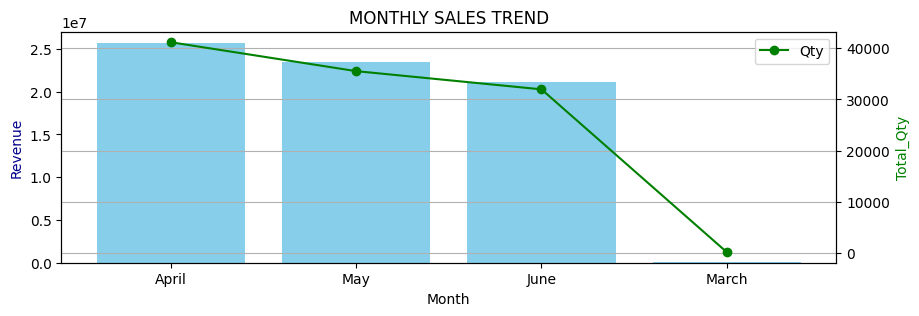

In [ ]:
fig, ax1 = plt.subplots(figsize=(10,3))

# First axis (Orders as bar)
ax1.bar(Month_sale['Order_month'],Month_sale['Amount'], color='skyblue', label='Amount')
ax1.set_xlabel("Month")
ax1.set_ylabel("Revenue", color='darkblue')

# Second axis (Revenue as line)
ax2 = ax1.twinx()
ax2.plot(Month_sale['Order_month'],Month_sale['Qty'], color='green', marker='o', label='Qty')
ax2.set_ylabel("Total_Qty", color='green')
plt.title("MONTHLY SALES TREND")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(loc='upper right')
plt.show()


In [ ]:
Sum=Net_order[['Amount','Qty']].sum()
Max=Net_order[['Amount','Qty']].max()
Min=Net_order[['Amount','Qty']].min()
AOV=Net_order[['Amount','Qty']].sum()/Net_order['Order ID'].nunique()

In [ ]:
AOV=AOV.round(2)

In [ ]:
# -------------------- Dataset Summary --------------------

# Generating statistical summary (mean, std, min, max, sum)
Summary=pd.DataFrame([Sum,Max,AOV,Min],index=['Sum','Max','AOV','Min'])
Summary

,Amount,Qty
Sum,70395197.62,108836.00
Max,5584.00,15.00
AOV,695.87,1.08
Min,0.00,0.00


In [ ]:
# -------------------- Revenue by State --------------------

# Grouping by 'ship-state' and summing sales amount

State_revenue=Net_order.groupby('ship-state')['Amount'].sum().reset_index(name='Net_Sale').sort_values('Net_Sale',ascending=False)
Top_State=State_revenue.head(10)
below_State=State_revenue.tail(10)



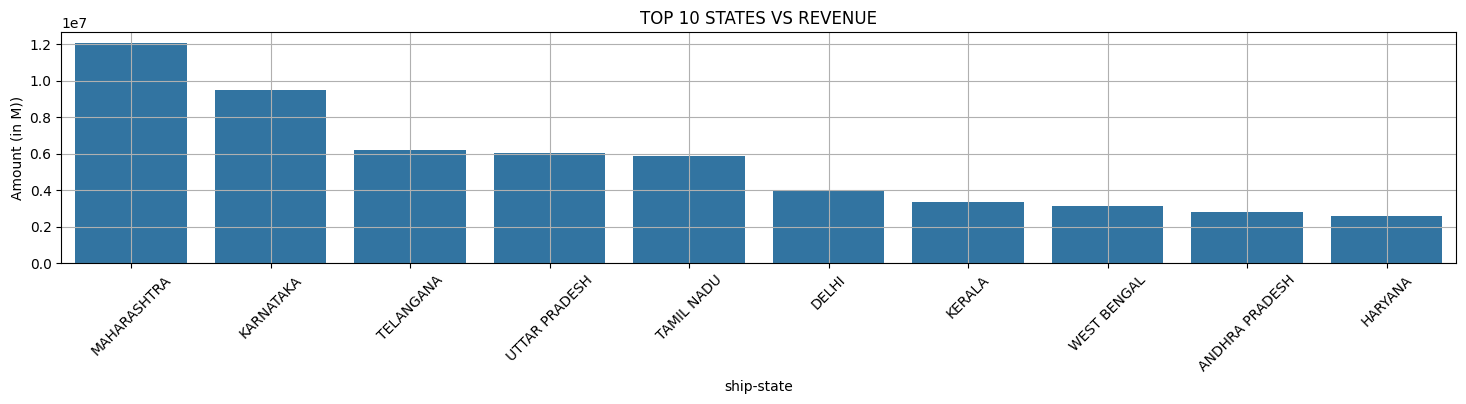

In [ ]:
plt.figure(figsize=(18,3))
sns.barplot(data=Top_State,x='ship-state',y='Net_Sale')
plt.xlabel('ship-state')
plt.ylabel('Amount (in M))')
plt.title('TOP 10 STATES VS REVENUE')
plt.xticks(rotation=45)
plt.grid(True)


plt.show()

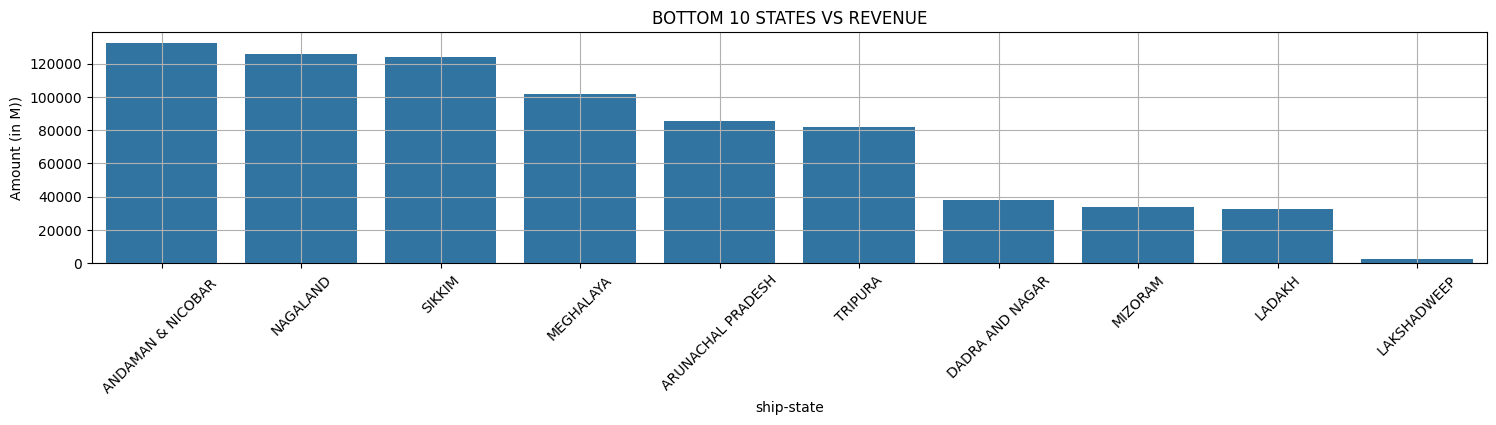

In [ ]:
plt.figure(figsize=(18,3))
sns.barplot(data=below_State,x='ship-state',y='Net_Sale')
plt.xlabel('ship-state')
plt.ylabel('Amount (in M))')
plt.title('BOTTOM 10 STATES VS REVENUE')
plt.xticks(rotation=45)
plt.grid(True)


plt.show()

In [ ]:
# -------------------- Quantity Sold by Date --------------------

# Grouping by 'Date' and summing quantities

Date_qty=Gross_orders.groupby(['Date'])['Qty'].sum().reset_index(name='Total_Qty').sort_values('Total_Qty',ascending=False)
Date_qty

,Date,Total_Qty
32,2022-05-02,1889
33,2022-05-03,1863
34,2022-05-04,1811
20,2022-04-20,1697
14,2022-04-14,1696
...,...,...
84,2022-06-23,965
86,2022-06-25,940
85,2022-06-24,935
90,2022-06-29,627


In [ ]:
# -------------------- Revenue by Product Category --------------------

# Grouping by 'Category' and calculating both sales amount & quantity

Category_revenue=Net_order.groupby('Category')[['Amount','Qty']].sum().sort_values('Amount',ascending=False).round(2)
Category_revenue['Average_Price']=Net_order.groupby('Category')[['Amount']].mean().round(2)
Category_revenue['Total_Orders']=Net_order.groupby('Category')[['Order ID']].count()



In [ ]:
Category_revenue['AOV']=Category_revenue['Amount']/Category_revenue['Total_Orders']


In [ ]:
Category_revenue

,Amount,Qty,Average_Price,Total_Orders,AOV
Category,,,,,
Set,35083217.14,42175,833.53,42090,833.528561
kurta,19132448.48,42018,457.12,41854,457.123536
Western Dress,9956020.00,13069,764.38,13025,764.377735
Top,4840417.00,9229,525.50,9211,525.503963
Ethnic Dress,720414.00,998,723.31,996,723.307229
Blouse,414009.00,820,518.81,798,518.808271
Bottom,134061.00,378,358.45,374,358.451872
Saree,113696.00,146,800.68,142,800.676056
Dupatta,915.00,3,305.00,3,305.000000


In [ ]:
Top_4_category=Category_revenue.head(5)
Below_4_category=Category_revenue.tail(5)

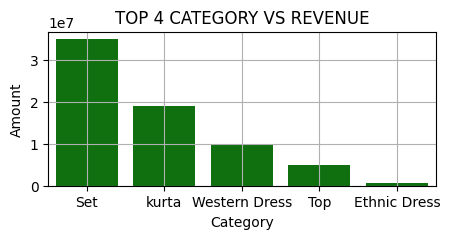

In [ ]:

plt.figure(figsize=(5,2))
sns.barplot(data=Top_4_category,x='Category',y='Amount',color='g')
plt.title('TOP 4 CATEGORY VS REVENUE')
plt.xlabel('Category')
plt.ylabel('Amount')
plt.grid(True)




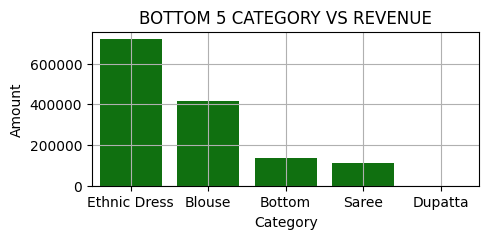

In [ ]:
plt.figure(figsize=(5,2))
sns.barplot(data=Below_4_category,x='Category',y='Amount',color='g')
plt.title('BOTTOM 5 CATEGORY VS REVENUE')
plt.xlabel('Category')
plt.ylabel('Amount')
plt.grid(True)


In [ ]:
# --------------------Top 10 Products by Revenue --------------------

# Grouping by SKU (Stock Keeping Unit), summing Amount & Qty
# Sorting by sales amount and selecting the top 10 products

top_10_Product=Net_order.groupby('SKU')[['Amount','Qty']].sum().sort_values('Amount',ascending=False).head(10)
top_10_Product.reset_index(inplace=True)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'J0230-SKD-M'),
  Text(1, 0, 'JNE3797-KR-L'),
  Text(2, 0, 'J0230-SKD-S'),
  Text(3, 0, 'JNE3797-KR-M'),
  Text(4, 0, 'JNE3797-KR-S'),
  Text(5, 0, 'JNE3797-KR-XL'),
  Text(6, 0, 'J0230-SKD-L'),
  Text(7, 0, 'JNE3797-KR-XS'),
  Text(8, 0, 'SET268-KR-NP-XL'),
  Text(9, 0, 'JNE3797-KR-XXXL')])

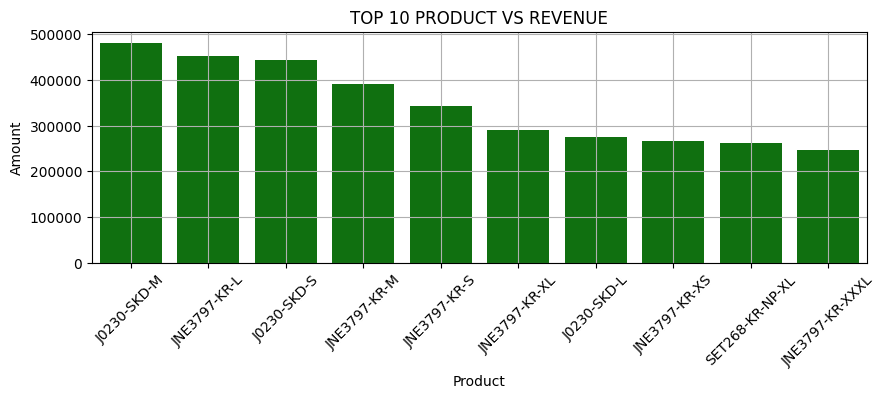

In [ ]:
plt.figure(figsize=(10,3))
sns.barplot(data=top_10_Product,x='SKU',y='Amount',color='g')
plt.title('TOP 10 PRODUCT VS REVENUE')
plt.xlabel('Product')
plt.ylabel('Amount')
plt.grid(True)
plt.xticks(rotation=45)



In [ ]:
# -------------------- Revenue by Fulfilment Type --------------------

# Grouping by 'Fulfilment' (e.g., FBA, Merchant, etc.)
# Calculating total Amount & Qty for each fulfillment type

Size_revenue=Net_order.groupby('Size')[['Amount','Qty']].sum().sort_values('Amount',ascending=False)
Size_revenue.reset_index(inplace=True)

In [ ]:
Top_5_size=Size_revenue.head(6)
Below_5_size=Size_revenue.tail(4)

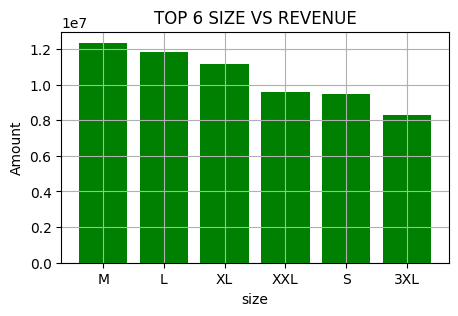

In [ ]:
plt.figure(figsize=(5,3))
plt.bar(Top_5_size['Size'],Top_5_size['Amount'],color='g')
plt.title('TOP 6 SIZE VS REVENUE')
plt.xlabel('size')
plt.ylabel('Amount')
plt.grid(True)

plt.show()

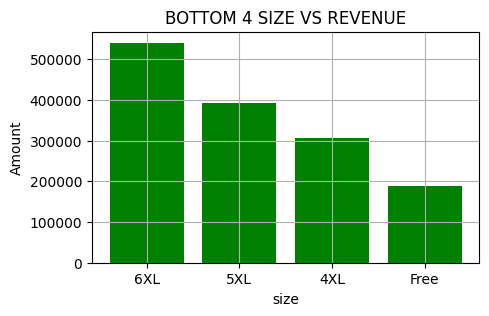

In [ ]:
plt.figure(figsize=(5,3))
plt.bar(Below_5_size['Size'],Below_5_size['Amount'],color='g')
plt.title('BOTTOM 4 SIZE VS REVENUE')
plt.xlabel('size')
plt.ylabel('Amount')
plt.grid(True)

plt.show()

In [ ]:

# -------------------- Revenue by Fulfilment Type --------------------

# Grouping by 'Fulfilment' (e.g., FBA, Merchant, etc.)
# Calculating total Amount & Qty for each fulfillment type

fulfillment_revenue=Net_order.groupby('Fulfilment')[['Amount','Qty']].sum().sort_values('Amount',ascending=False)
fulfillment_revenue.reset_index(inplace=True)

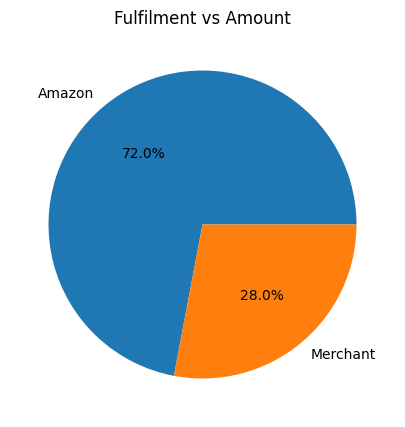

In [ ]:
plt.figure(figsize=(15,5))
plt.pie(fulfillment_revenue['Amount'],labels=fulfillment_revenue['Fulfilment'],autopct='%1.1f%%')
plt.title('Fulfilment vs Amount')
plt.show()

In [ ]:

# -------------------- Renaming Columns --------------------

# Renaming columns for easier access (no spaces in names)
df2.rename(columns={'Sales Channel':'Sales_Channel','Courier Status':'Courier_Status'},inplace=True)

In [ ]:
# -------------------- B2B Revenue --------------------

# Grouping by 'B2B' flag to analyze business-to-business orders

B2B_revenue=df2.groupby('B2B')[['Amount','Qty']].sum().sort_values('Amount',ascending=False)
B2B_revenue

,Amount,Qty
B2B,,
False,78118962.15,115810
True,591807.79,841


In [ ]:
# -------------------- Checking Order Status Distribution --------------------

# Viewing frequency of each unique order status
order_delivery=Gross_orders.groupby(["Status"])["Order ID"].nunique().reset_index(name='Total_Orders')
order_delivery['Contribution(%)']=order_delivery['Total_Orders']/order_delivery['Total_Orders'].sum()*100


In [ ]:
order_delivery.round(2)

,Status,Total_Orders,Contribution(%)
0,Cancelled,17196,14.29
1,Dispatched - Not Picked Up,72797,60.49
2,Pending - Waiting for Pick Up,846,0.70
3,Shipped - Damaged,1,0.00
4,Shipped - Delivered to Buyer,26568,22.07
5,Shipped - Lost in Transit,4,0.00
6,Shipped - Out for Delivery,32,0.03
7,Shipped - Picked Up by Courier,918,0.76
8,Shipped - Rejected by Buyer,11,0.01
9,Shipped - Returned to Seller,1851,1.54


In [ ]:
Condition=[Gross_orders['Status'].isin(['Cancelled','Shipped - Damaged','Shipped - Lost in Transit','Shipped - Rejected by Buyer','Shipped - Returned to Seller','Shipped - Returning to Seller']),Gross_orders['Status']=='Shipped - Delivered to Buyer']

In [ ]:
choice=['Cancelled','Delivered']


In [ ]:
Gross_orders['Delivery_status']=np.select(Condition,choice,default='Pending')

In [ ]:
delivery_status=Gross_orders.groupby(['Delivery_status'])['Order ID'].nunique().reset_index(name='Orders')
delivery_status

,Delivery_status,Orders
0,Cancelled,19193
1,Delivered,26568
2,Pending,74593


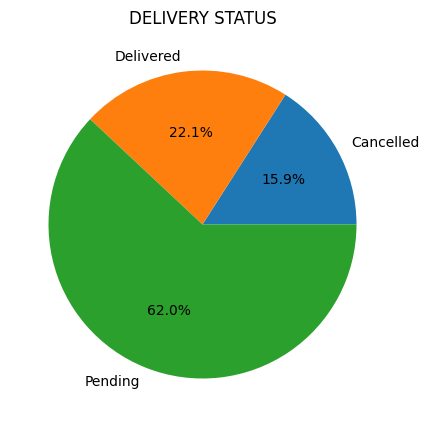

In [ ]:
plt.figure(figsize=(5,5))
plt.pie(delivery_status['Orders'],labels=delivery_status['Delivery_status'],autopct='%1.1f%%')
plt.title('DELIVERY STATUS')
plt.show()

In [ ]:
# -------------------- Analyzing Cancelled Orders by Date --------------------

# Grouping cancelled orders by 'Date'
# Counting how many orders were cancelled each day


order_cancel_date=Cancelled_order.groupby(['Date'])['Status'].count().reset_index(name='Total_Cancelled').sort_values('Date',ascending=False)
order_cancel_date

,Date,Total_Cancelled
90,2022-06-29,31
89,2022-06-28,162
88,2022-06-27,141
87,2022-06-26,159
86,2022-06-25,137
...,...,...
4,2022-04-04,214
3,2022-04-03,263
2,2022-04-02,267
1,2022-04-01,255


In [ ]:
Cancelled_order['Order_month']=Cancelled_order['Date'].dt.strftime('%B')

In [ ]:
order_cancel_month = Cancelled_order.groupby(['Order_month'])['Order ID'].nunique()


In [ ]:
Month_orders=Gross_orders.groupby(['Order_month'])['Order ID'].nunique()


In [ ]:
cancellation_summary=pd.DataFrame({'Total_orders':Month_orders,'Orders_cancelled':order_cancel_month}).fillna(0)


In [ ]:
cancellation_summary['Cancellation_rate%']=(cancellation_summary['Orders_cancelled']/cancellation_summary['Total_orders']*100).round(2)

In [ ]:
cancellation_summary.reset_index('Order_month',inplace=True)

In [ ]:
cancellation_summary

,Order_month,Total_orders,Orders_cancelled,Cancellation_rate%
0,April,45849,7589,16.55
1,June,35129,5422,15.43
2,March,158,19,12.03
3,May,39216,6163,15.72


In [ ]:
cancellation_summary.Total_orders.sum()

np.int64(120352)

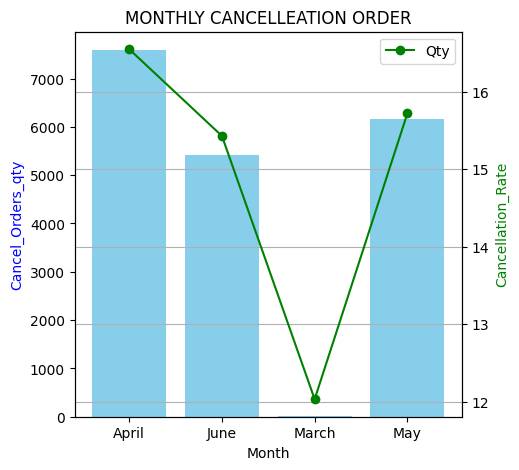

In [ ]:
fig, ax1 = plt.subplots(figsize=(5,5))

# First axis (Orders as bar)
ax1.bar(cancellation_summary['Order_month'],cancellation_summary['Orders_cancelled'], color='skyblue', label='Total_orders')
ax1.set_xlabel("Month")
ax1.set_ylabel("Cancel_Orders_qty", color='blue')

# Second axis (Revenue as line)
ax2 = ax1.twinx()
ax2.plot(cancellation_summary['Order_month'],cancellation_summary['Cancellation_rate%'], color='green', marker='o', label='Qty')
ax2.set_ylabel("Cancellation_Rate", color='green')
plt.title("MONTHLY CANCELLEATION ORDER")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(loc='upper right')
plt.show()

In [ ]:
cancellation_summary['Orders_cancelled'].sum()

np.int64(19193)

In [ ]:
Gross_orders['Day_name']=Gross_orders['Date'].dt.day_name()
Net_order['Day_name']=Net_order['Date'].dt.day_name()
Cancelled_order['Day_name']=Cancelled_order['Date'].dt.day_name()

In [ ]:
Day_Sale=Net_order.groupby('Day_name')[['Amount','Qty']].sum().sort_values('Amount',ascending=False)

In [ ]:
Day_Sale['Average_AOV']=Day_Sale['Amount']/Day_Sale['Qty']

In [ ]:
Day_Sale.reset_index(inplace=True)

In [ ]:
Day_Sale['Week_day']=pd.Categorical(Day_Sale['Day_name'],categories=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'],ordered=True)
Day_Sale.sort_values('Week_day')

,Day_name,Amount,Qty,Average_AOV,Week_day
4,Monday,10091903.00,15613,646.378210,Monday
1,Tuesday,10276862.00,15867,647.687780,Tuesday
3,Wednesday,10113269.00,15705,643.952181,Wednesday
6,Thursday,9318096.00,14443,645.163470,Thursday
5,Friday,9672546.00,14915,648.511297,Friday
2,Saturday,10126616.62,15662,646.572380,Saturday
0,Sunday,10795905.00,16631,649.143467,Sunday


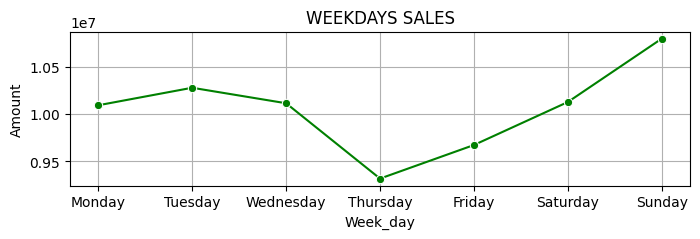

In [ ]:
plt.figure(figsize=(8,2))
sns.lineplot(data=Day_Sale,x='Week_day',y='Amount',marker='o',color='g')
plt.title('WEEKDAYS SALES')
plt.grid(True)



plt.show()

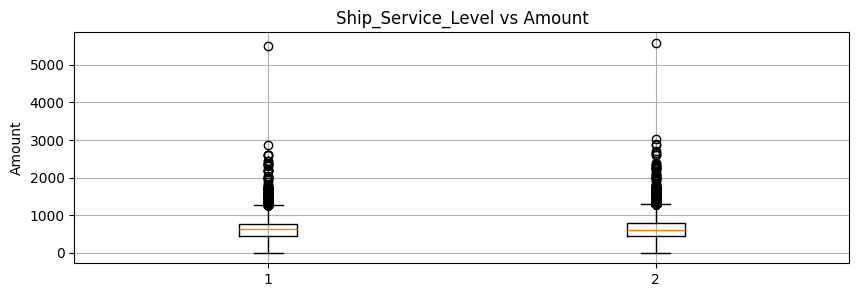

In [ ]:
plt.figure(figsize=(10,3))
plt.boxplot([Net_order['Amount'][Net_order['ship-service-level']==level] for level in Net_order['ship-service-level'].unique()])
plt.xticks(rotation=0)
plt.ylabel('Amount')
plt.title('Ship_Service_Level vs Amount')
plt.grid()
plt.show()

In [ ]:
City_Sale=Net_order.groupby('ship-city')['Amount'].sum().reset_index(name='Net_Amount').sort_values('Net_Amount',ascending=False).head(20)

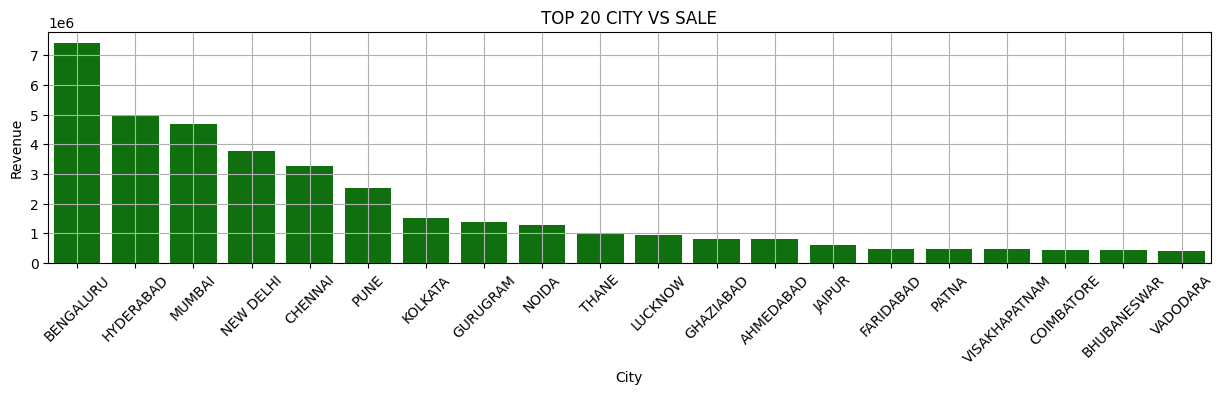

In [ ]:
plt.figure(figsize=(15,3))
sns.barplot(data=City_Sale,x='ship-city',y='Net_Amount',color='g')
plt.xlabel('City')
plt.ylabel('Revenue')
plt.title('TOP 20 CITY VS SALE')
plt.xticks(rotation=45)
plt.grid(True)


plt.show()

In [ ]:
##from google.colab import files

# Save dataframe as Excel
##Gross_orders.to_csv("E-Commerce_data.csv", index=False)

# Download to your computer
##files.download("E-Commerce_data.csv")


**Financial Performances:**

*   *Total Sales Revenue: 70395197.62*
*   *Total Orders: 108836*
*   *Max Order value: 5584.00*
*   *Average order value: 695.87*






**Product Performance**:

*   *Set and Kurta had the highest sales*
*   *Saree,dupatta and top had lowest sales*




**Logistics Performance**

*   *May & June orders have not been delivered yet*
*   *Overall 15% of total orders were cancelled including those which were      returned and damaged*





**Sales Analysis**

*   *Highest Sales: 2,3,4 May i.e 10M+*
*   *Lowest Sales: 29 July i.e 4Lakh+*

**State wise Highest Sale**:
*   *MAHARASHTRA	12065290.00
*   *KARNATAKA	9520784.00*
*   *TELANGANA	6188331.57*
*   *UTTAR PRADESH	6022245.00*
*   *TAMIL NADU	5865031.00*

**State wise Lowest Sale**:
*   #*ARUNACHAL PRADESH	85544.0*
*   *TRIPURA	81614.0*
*   *DADRA AND NAGAR	37936.0*
*   *MIZORAM	33808.0*
*   *LADAKH	32785.0*
*   *LAKSHADWEEP	2441.0*

**Day wise Sales**
*   *Sunday had a highest sales among others*
*   *Thrusday & Friday had Lowest sales*

**City wise Sales:**
*   *Bengaluru: 7.4M+*
*   *Hyderabad: 5M+*
*   *Mumbai: 4.6M+*
*   *New Delhi: 3.7M+*
*   *Chennai: 3.2M+*


**Recomendations**

**Product Recomendation:**
* *Introduce more styles, colors, and designs within the "Set" and "Kurta" categories.*
* *Ensure we have sufficient stock of the best-selling "Set" and "Kurta" items to prevent stockouts and lost sales.*
* *Conduct a deep-dive analysis into the reasons for the low sales of "Saree," "Dupatta," and "Top" and implement a strategy to improve their performance.*


**Logistics Recommendaton:**
* *Launch an immediate investigation to determine why these specific orders were not delivered. Was it a logistics partner issue? A warehouse problem? Incorrect addresses?*
* *Develop a strategic initiative to systematically reduce the order cancellation, return, and damage rate, targeting a more acceptable industry standard (typically below 5-10%).*



**Sales Recommendation:**
* *Analyze the factors behind the consistently high sales in late April and early May to create a repeatable strategy.*
* *Allocate more resources to our top-performing states and cities, while reconsidering our approach to low-performing regions*
* *Leverage our strongest sales day, Sunday, while implementing strategies to boost sales on our weakest days, Thursday and Friday.*



                              ##THANK YOU##

